# **Step 1 - Defining business requirement: Predicting liver disease**

 link to get the dataset:
 http://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset

In [5]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Set font globally
plt.rcParams['font.family'] = 'Liberation Serif'
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

!pip install optuna

# **Step 2 - Explore data or information**

Step 2.1 - Reading the .CSV file for the patient data

In [6]:
df = pd.read_csv('/Indian Liver Patient Dataset (ILPD).csv', header=None)

Step 2.2 - Since the data received does not have the column headers, adding them.

In [7]:
df.columns = ["Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
              "Alkaline_Phosphotase", "Alamine_Aminotransferase",
              "Aspartate_Aminotransferase", "Total_Protiens",
              "Albumin", "Albumin_and_Globulin_Ratio",
              "Has_liver_disease(Yes_1, No_2)"]

Step 2.3 - Explore the structure of the dataset, number of rows and columns

In [8]:
print('Total number of rows are',df.shape[0])
print('Total number of columns are',df.shape[1])

Total number of rows are 583
Total number of columns are 11


Step 2.4 - Explore the high level structure of the dataset to see how the dataset look like.

In [9]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,"Has_liver_disease(Yes_1, No_2)"
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


# **Step 3- Analysing Data**

Step 3.1 - Analysing the datatypes of columns

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             583 non-null    int64  
 1   Gender                          583 non-null    object 
 2   Total_Bilirubin                 583 non-null    float64
 3   Direct_Bilirubin                583 non-null    float64
 4   Alkaline_Phosphotase            583 non-null    int64  
 5   Alamine_Aminotransferase        583 non-null    int64  
 6   Aspartate_Aminotransferase      583 non-null    int64  
 7   Total_Protiens                  583 non-null    float64
 8   Albumin                         583 non-null    float64
 9   Albumin_and_Globulin_Ratio      579 non-null    float64
 10  Has_liver_disease(Yes_1, No_2)  583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
None


Step 3.2 - Descriptive Analysis of each column

In [11]:
# Descriptive Analysis of each column
for features in df.columns:
  print('----***Describing',features,'***----','\n')
  print(df[features].describe())
  print('--------------------')

----***Describing Age ***---- 

count    583.000000
mean      44.746141
std       16.189833
min        4.000000
25%       33.000000
50%       45.000000
75%       58.000000
max       90.000000
Name: Age, dtype: float64
--------------------
----***Describing Gender ***---- 

count      583
unique       2
top       Male
freq       441
Name: Gender, dtype: object
--------------------
----***Describing Total_Bilirubin ***---- 

count    583.000000
mean       3.298799
std        6.209522
min        0.400000
25%        0.800000
50%        1.000000
75%        2.600000
max       75.000000
Name: Total_Bilirubin, dtype: float64
--------------------
----***Describing Direct_Bilirubin ***---- 

count    583.000000
mean       1.486106
std        2.808498
min        0.100000
25%        0.200000
50%        0.300000
75%        1.300000
max       19.700000
Name: Direct_Bilirubin, dtype: float64
--------------------
----***Describing Alkaline_Phosphotase ***---- 

count     583.000000
mean      290.57632

Step 3.3 - Visual Analysis of some key features

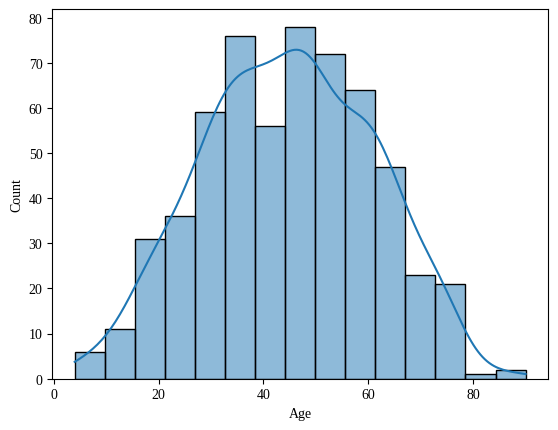

In [12]:

#Let's see the age distribution of the patients
ageplot = sns.histplot(df['Age'], kde=True)

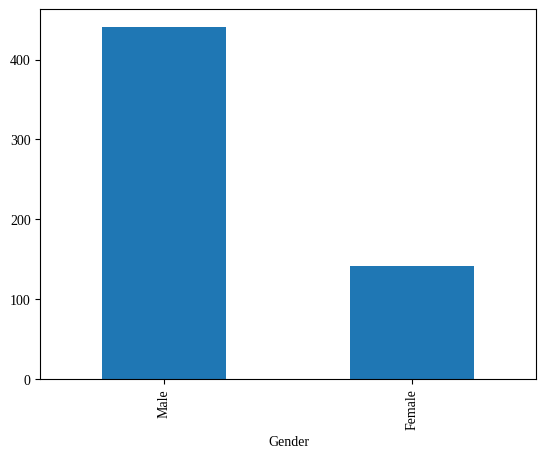

In [13]:
#Let's see the gender distribution of patients
gender_dist = df['Gender'].value_counts().plot(kind='bar')

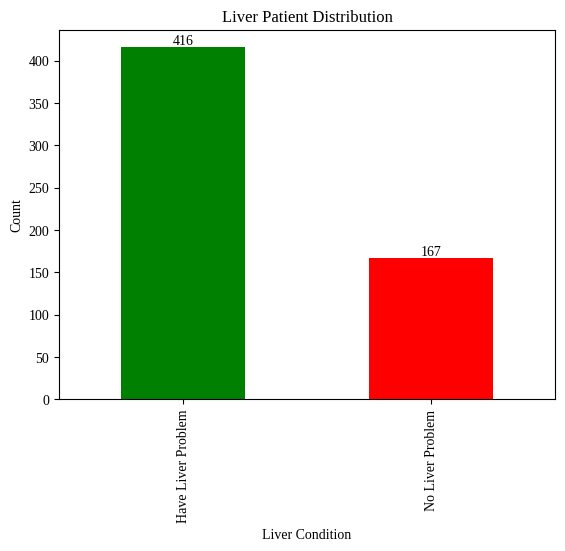

In [14]:
#As per data, how many patients have liver problem or not

lp = df['Has_liver_disease(Yes_1, No_2)'].value_counts().sort_index().plot(kind='bar', color=['green', 'red'])

lp.set_xticks([0, 1])
lp.set_xticklabels(['Have Liver Problem','No Liver Problem'])  # Set the labels

# Add labels and title
lp.set_xlabel('Liver Condition')
lp.set_ylabel('Count')
lp.set_title('Liver Patient Distribution')
for p in lp.patches:
    lp.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

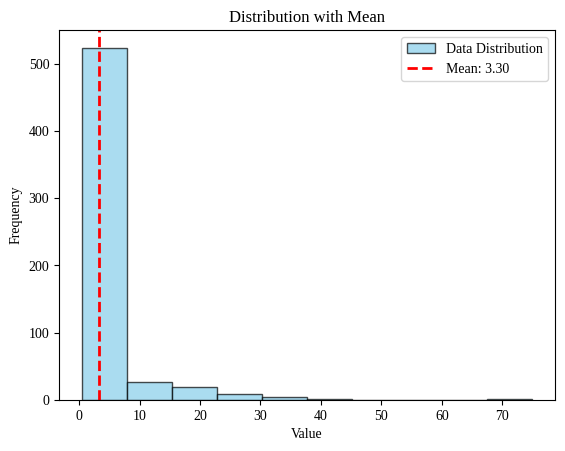

In [15]:
#Plotting the distribution of Total_bilirubin with mean

# Example data
data = df['Total_Bilirubin']

# Calculate mean
mean_value = np.mean(data)

# Plot the data as a histogram
plt.hist(data, bins=10, alpha=0.7, color='skyblue', edgecolor='black', label="Data Distribution")

# Add a line for the mean
plt.axvline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')

# Add labels and legend
plt.title('Distribution with Mean')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.show()


In [16]:
#Find the discrete & continuos variable in the data
discrete_threshold = 10
continuos_variables = []
discrete_variables = []
for i in df.columns:
  lenn = len(df[i].unique())
  if lenn<discrete_threshold:
    discrete_variables.append(i)
    print(i,df[i].unique())
    print(df[i].value_counts())
    print('---------------------')
  else:
    continuos_variables.append(i)
print('---------------------')
print('continuos_variables',continuos_variables)
print('---------------------')
print('discrete_variables',discrete_variables)

Gender ['Female' 'Male']
Gender
Male      441
Female    142
Name: count, dtype: int64
---------------------
Has_liver_disease(Yes_1, No_2) [1 2]
Has_liver_disease(Yes_1, No_2)
1    416
2    167
Name: count, dtype: int64
---------------------
---------------------
continuos_variables ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
---------------------
discrete_variables ['Gender', 'Has_liver_disease(Yes_1, No_2)']


*But the above data may not be as accurate as we found some of the rows are having just 'space' so it is better to convert the data to right datatype and handle the null values, if exists *

Step 3.4 -  Handling String type columns

In [17]:
#Find no. of column string type
for i in df.columns:
  if df[i].dtypes == 'object':
    df[i] = df[i].replace(' ','')
    print(i)


Gender


Step 3.5 - Changing the type and handling missing values wherever applicable

In [18]:
#Making changes in the Gender column without any Ordinal dependency
df['Gender']= df['Gender'].replace({'Male': 1, 'Female': 0})

#Making changes in the type of Total_biliribin columns
df['Total_Bilirubin'] = pd.to_numeric(df['Total_Bilirubin'], errors='coerce')
df['Total_Bilirubin'].fillna(df['Total_Bilirubin'].mode()[0],inplace=True)

#Making changes in the type of Direct_biliribin columns
df['Direct_Bilirubin'] = pd.to_numeric(df['Direct_Bilirubin'], errors='coerce')
df['Direct_Bilirubin'].fillna(df['Direct_Bilirubin'].mode()[0],inplace=True)

#Making changes in the type of Alkaline_Phosphotase columns
df['Alkaline_Phosphotase'] = pd.to_numeric(df['Alkaline_Phosphotase'], errors='coerce')
df['Alkaline_Phosphotase'].fillna(df['Alkaline_Phosphotase'].mode()[0],inplace=True)

#Making changes in the type of Alamine_Aminotransferase columns
df['Alamine_Aminotransferase'] = pd.to_numeric(df['Alamine_Aminotransferase'], errors='coerce')
df['Alamine_Aminotransferase'].fillna(df['Alamine_Aminotransferase'].mode()[0],inplace=True)

#Making changes in the type of Aspartate_Aminotransferase columns
df['Aspartate_Aminotransferase'] = pd.to_numeric(df['Aspartate_Aminotransferase'], errors='coerce')
df['Aspartate_Aminotransferase'].fillna(df['Aspartate_Aminotransferase'].mode()[0],inplace=True)

#Making changes in the type of Total_Protiens columns
df['Total_Protiens'] = pd.to_numeric(df['Total_Protiens'], errors='coerce')
df['Total_Protiens'].fillna(df['Total_Protiens'].mode()[0],inplace=True)

#Filling null values in Albumin_and_Globulin_Ratio column
df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].mode()[0],inplace=True)

Step 3.6 - Validating there are no null values in the dataset now.

In [19]:
#Check for null values to ensure there is no null values
df.isnull().sum().sort_values(ascending=False)

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,0


Step 3.7 - Re-analysing the dataset after transformation.

In [20]:
for features in df.columns:
  print('----***Describing',i,'***----','\n')
  print(df[features].describe())
  print('--------------------')

----***Describing Has_liver_disease(Yes_1, No_2) ***---- 

count    583.000000
mean      44.746141
std       16.189833
min        4.000000
25%       33.000000
50%       45.000000
75%       58.000000
max       90.000000
Name: Age, dtype: float64
--------------------
----***Describing Has_liver_disease(Yes_1, No_2) ***---- 

count    583.000000
mean       0.756432
std        0.429603
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Gender, dtype: float64
--------------------
----***Describing Has_liver_disease(Yes_1, No_2) ***---- 

count    583.000000
mean       3.298799
std        6.209522
min        0.400000
25%        0.800000
50%        1.000000
75%        2.600000
max       75.000000
Name: Total_Bilirubin, dtype: float64
--------------------
----***Describing Has_liver_disease(Yes_1, No_2) ***---- 

count    583.000000
mean       1.486106
std        2.808498
min        0.100000
25%        0.200000
50%        0.300000
75%     

Step 3.8 - Data analysis for feature extraction

Univariate way


*   To check too uniform
*   To check too diverse
*   To check too low

Bivaraite way
*   Pairwise Corelation


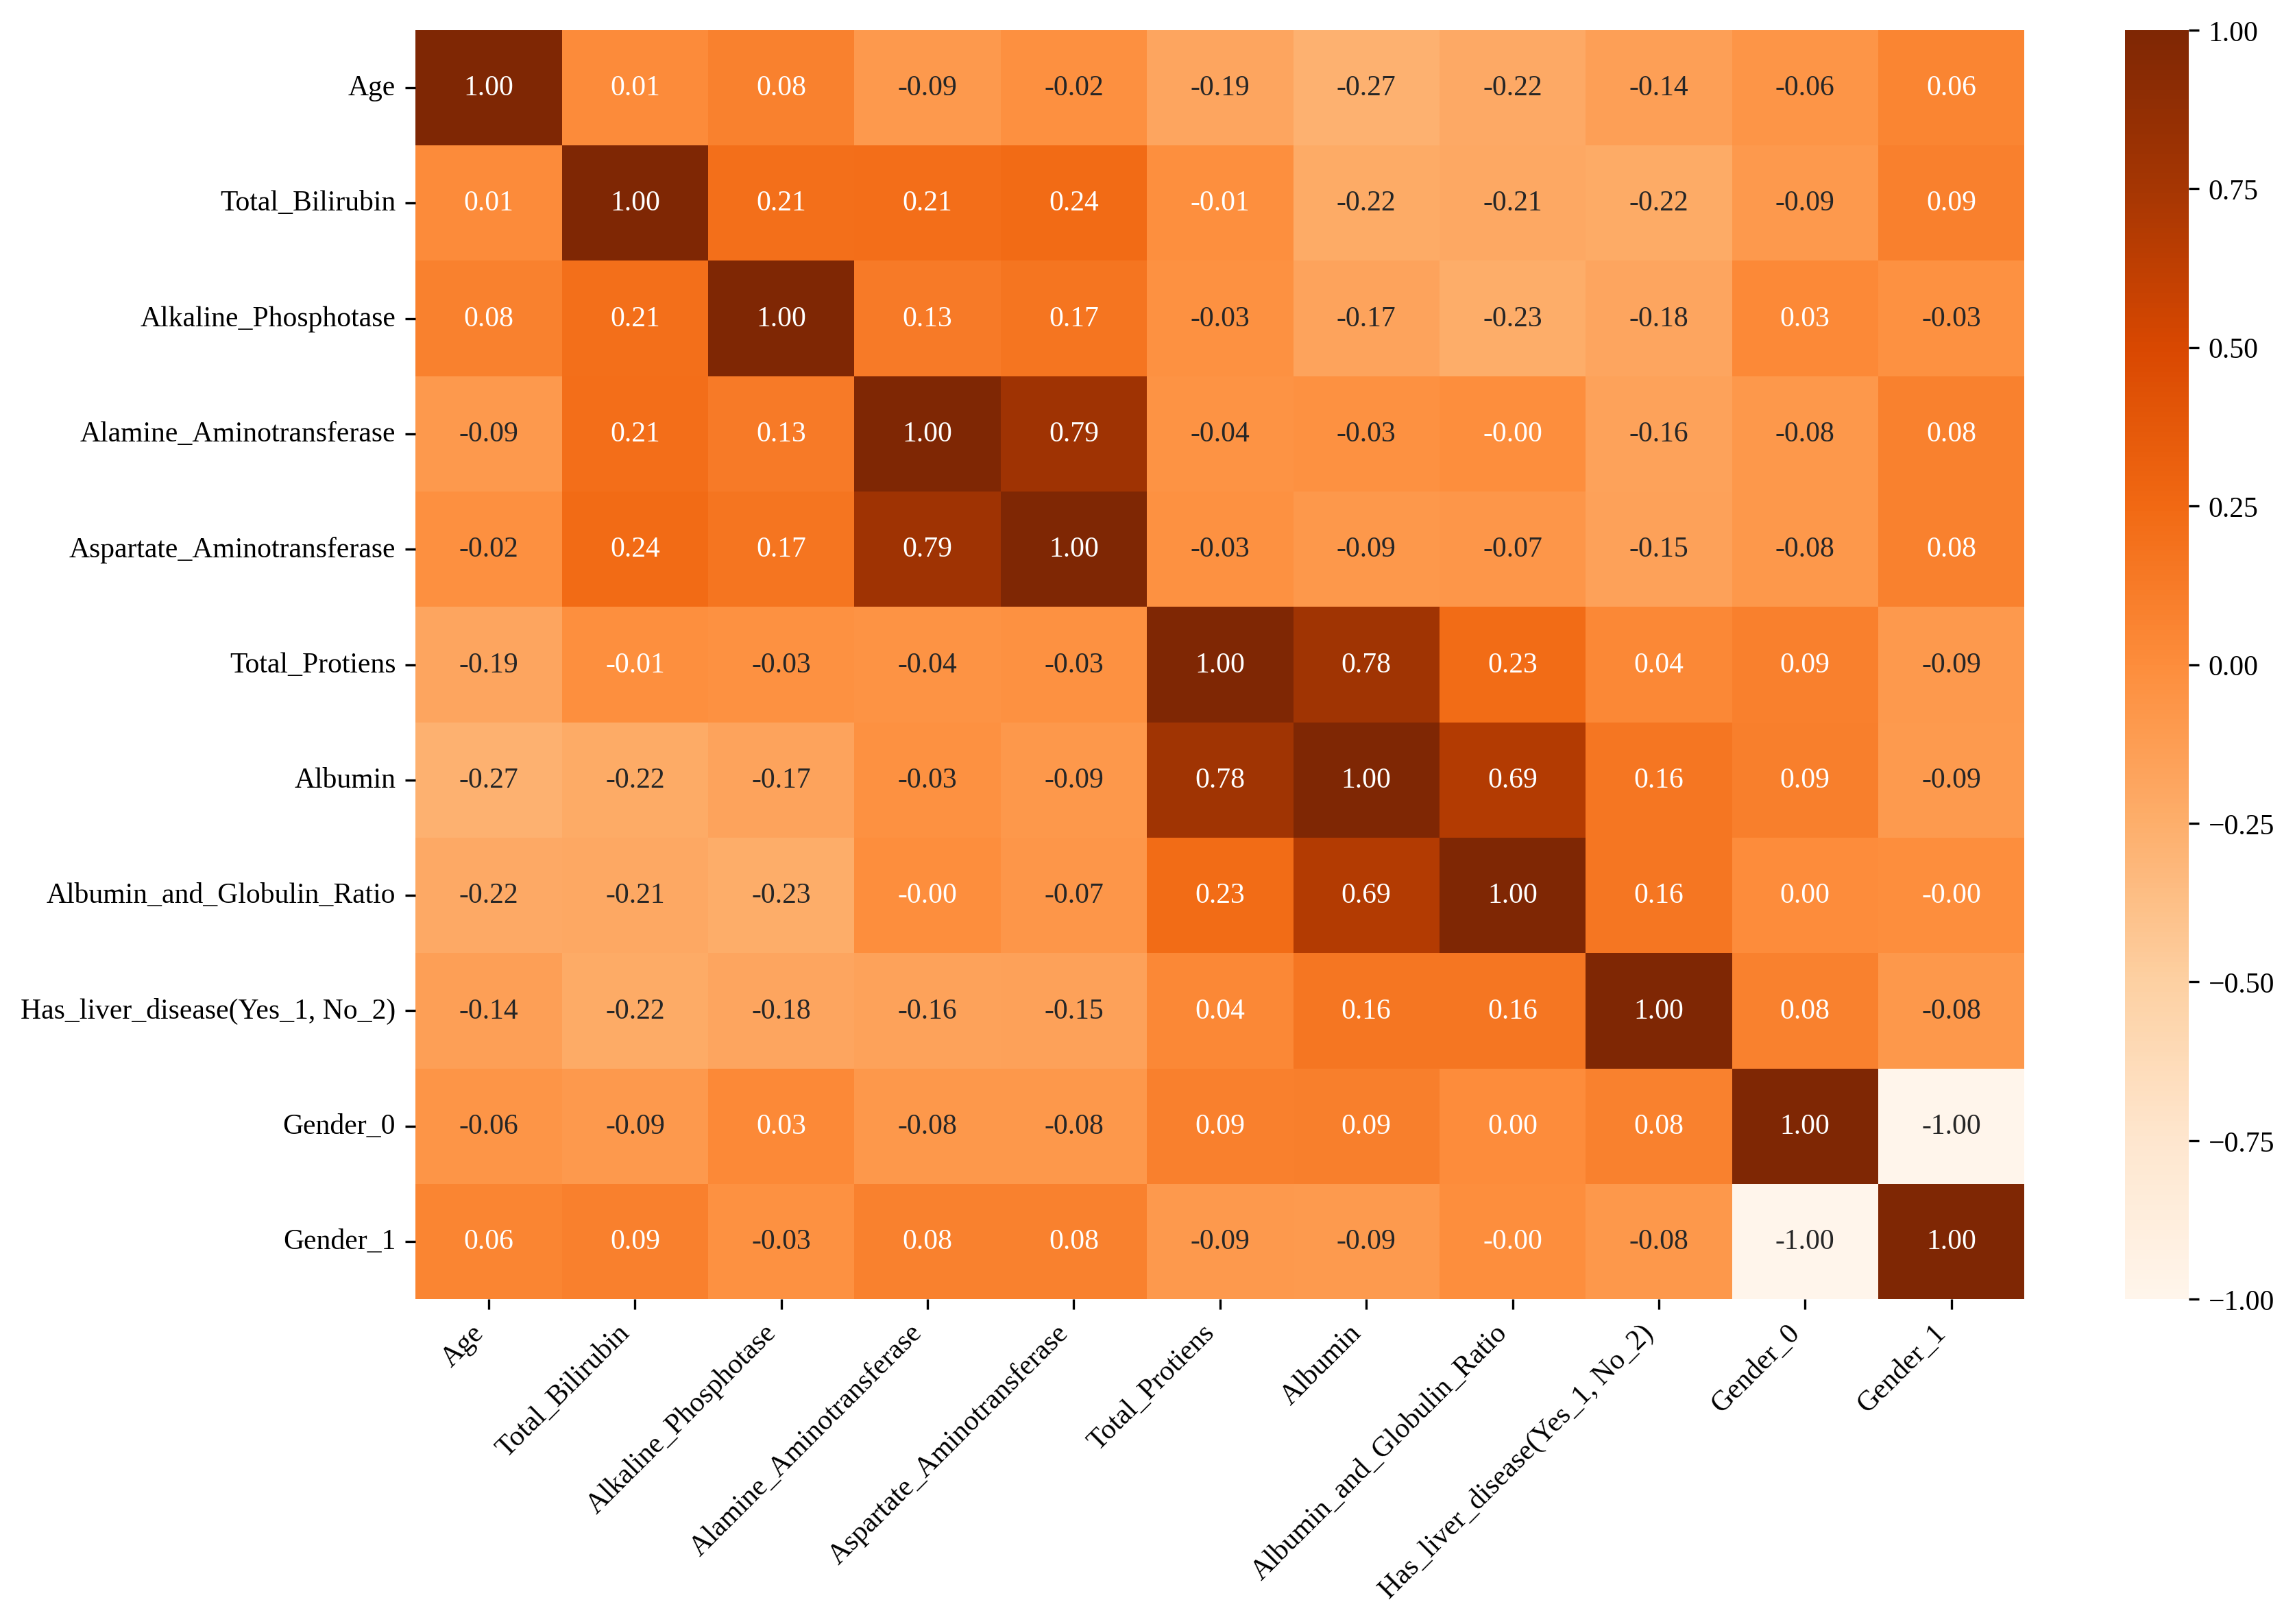

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create high-resolution figure
plt.figure(figsize=(12, 8), dpi=300)

corr = df.corr()

ax = sns.heatmap(corr,
                 cmap="Oranges",
                 annot=True,
                 fmt=".2f",
                 annot_kws={"size": 10})

# Better label formatting
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr.columns, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

**Conclusion :** *From bivariate analysis, we can conclude that Total_Bilirubin & Direct_Bilirubin are quite corelated with 87% and one of them can be removed.*

Step 3.9 - Removing the unnecessary columns

In [22]:
#Dropping the Direct_bilirubin column
df.drop(['Direct_Bilirubin'],axis=1,inplace=True)

Step 3.10 - Applying 1 hot encoding to relavant columns, since most ML algorithms work with numbers.

In [23]:
#First find the discrete & continuous columns in the data
discrete_threshold = 10
continuos_variables = []
discrete_variables = []
for i in df.columns:
  lenn = len(df[i].unique())
  if lenn<discrete_threshold:
    discrete_variables.append(i)
    print(i,df[i].unique())
    print(df[i].value_counts())
    print('---------------------')
  else:
    continuos_variables.append(i)
print('---------------------')
print('continuos_variables',continuos_variables)
print('---------------------')
print('discrete_variables',discrete_variables)

Gender [0 1]
Gender
1    441
0    142
Name: count, dtype: int64
---------------------
Has_liver_disease(Yes_1, No_2) [1 2]
Has_liver_disease(Yes_1, No_2)
1    416
2    167
Name: count, dtype: int64
---------------------
---------------------
continuos_variables ['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
---------------------
discrete_variables ['Gender', 'Has_liver_disease(Yes_1, No_2)']


In [24]:
#Applying 1 hot encoding on the Gender column so that there is no Ordinal dependency
df['Gender']= df['Gender'].replace({'Male': 1, 'Female': 0})
df = pd.concat([df, pd.get_dummies(df['Gender'], prefix='Gender')], axis=1)
df = df.drop(columns=['Gender'])

# **Step 4 Make prediction**

Step 4.1 - Selecting the data for training and test

In [25]:
training_features= ['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase',
       'Alamine_Aminotransferase', 'Aspartate_Aminotransferase',
       'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Gender_0', 'Gender_1']

target = ['Has_liver_disease(Yes_1, No_2)']
X_train, X_test, Y_train, Y_test = train_test_split(df[training_features],
                                                    df[target],
                                                    test_size=0.2,
                                                    random_state=12,
                                                    stratify=df[target],
                                                    shuffle=True)

Step 4.2 - Normalizing the data using Standard scalar

In [26]:
from sklearn.preprocessing import StandardScaler #Z = (X-mu)/sigma

# Assuming X_train and X_test are your training and testing data
scaler = StandardScaler()

# Fit the scaler on the training data
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

Step 4.3 - Using Decision Tree

In [27]:
from sklearn import tree
dt = tree.DecisionTreeClassifier(
  max_depth=5,
  min_samples_split=2,
  min_samples_leaf=2,
  max_features=10,
  random_state=42,
  criterion='entropy',
  )
dt.fit(X_train, Y_train)

predicted=dt.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(Y_test, predicted))

Accuracy: 0.6923076923076923


Step 4.4 - Predicting the liver disease using the manual input data

In [28]:
patient_data = np.array([[17,0.9,202,22,19,7.4, 4.1, 1.20,0,1]])

# Prediction
prediction = dt.predict(patient_data)

# Output result
if prediction[0] == 1:
    print("Result: Patient HAS Liver Disease")
else:
    print("Result: Patient DOES NOT have Liver Disease")

Result: Patient HAS Liver Disease


# **Step 5 Optimize**

Step 5.1 - Define the tuning parameters

In [29]:
import optuna
def tune(objective):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100)

    params = study.best_params
    best_score = study.best_value
    print(f"Best score: {best_score} \nOptimized parameters: {params}")
    return params

In [30]:
from sklearn.model_selection import KFold, cross_val_score
RANDOM_SEED = 42
kfolds = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

In [31]:
#Running permutation conbination for DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def DT_objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"])
    }

    model = DecisionTreeClassifier(**params, random_state=42)
    scores = cross_val_score(
        model,
        X_train,
        Y_train.values.ravel(),
        cv=kfolds,
        scoring='accuracy'
    )

    return scores.mean()

Step 5.2 - Optimize the model based on the tuning parameters

In [32]:
DT_params = tune(DT_objective)

[I 2026-04-03 03:50:35,091] A new study created in memory with name: no-name-21781b37-935e-4747-9bc0-f3e39f477fdb
[I 2026-04-03 03:50:35,139] Trial 0 finished with value: 0.6671600370027753 and parameters: {'max_depth': 2, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.6671600370027753.
[I 2026-04-03 03:50:35,180] Trial 1 finished with value: 0.6824236817761333 and parameters: {'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': None, 'criterion': 'gini'}. Best is trial 1 with value: 0.6824236817761333.
[I 2026-04-03 03:50:35,219] Trial 2 finished with value: 0.6866790009250694 and parameters: {'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'criterion': 'entropy'}. Best is trial 2 with value: 0.6866790009250694.
[I 2026-04-03 03:50:35,263] Trial 3 finished with value: 0.7038852913968547 and parameters: {'max_depth': 7, 'min_samples_split': 2, 'min

Best score: 0.7143848288621647 
Optimized parameters: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'criterion': 'entropy'}


Step 5.3 - Apply the optimized parameter to the existing model for better results.

In [33]:
dt_opt = tree.DecisionTreeClassifier(**DT_params, random_state=RANDOM_SEED)
dt_opt.fit(X_train, Y_train.values.ravel())

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=4,
                       random_state=42)

# **Step 6 Measure**

Step 6.1 - Testing the model accuracy on after the optimization

In [34]:
#checking the suggested optimized parameters from Optuna
predicted=dt_opt.predict(X_test)
print("Accuracy:",metrics.accuracy_score(Y_test, predicted))

Accuracy: 0.7094017094017094


# **Step 7 Reporting**


We tested 2 different scenarios and found below reqults.

1. Decision Tree(Before optimization)

* Accuracy score | 69.23%
---
2. Decision Tree(After optimization)

* Accuracy score | 70.94%


